# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**24012431**  
第5天专题（A/B/C/D/E）：**A**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012431"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012431
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,index,0
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单中位数,2.00
5,平均优惠券数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,平均订单数,平均优惠券数,平均返现金额,平均App使用时长,平均满意度,流失率
0,0-6个月,1642,2.68,1.74,164.87,3.14,3.09,0.26
1,13-24个月,1467,3.70,2.02,204.92,2.94,3.09,0.06
2,24个月以上,429,3.55,1.94,222.34,2.87,3.05,0.00
3,7-12个月,1584,2.75,1.60,163.31,2.88,2.99,0.10
4,新用户,508,1.89,0.96,142.44,2.51,3.18,0.54


,TenureGroup,PreferedOrderCat,用户数,流失人数,流失率,平均订单数,平均优惠券数,平均返现金额,平均App使用时长,平均满意度,样本提示
0,0-6个月,Others,5,4,0.80,12.80,4.60,307.97,2.60,3.00,小样本
1,新用户,Fashion,40,32,0.80,3.00,1.55,194.61,2.35,3.45,可观察
2,新用户,Mobile Phone,311,168,0.54,1.69,0.89,129.02,2.60,3.12,可观察
3,0-6个月,Grocery,25,12,0.48,4.16,2.68,259.40,2.88,3.24,小样本
4,新用户,Laptop & Accessory,155,72,0.46,1.95,0.95,154.18,2.35,3.21,可观察


检查点1A通过：输入文件有效


In [3]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同生命周期阶段用户的流失率是否存在差异？",
    "behavior_scatter": "返现金额与优惠券数呈现什么关系？",
    "ordered_line": "用户的平局订单数如何随用户生命周期变化？",
    "composition_chart": "全体用户由哪些订单偏好类别构成？",
}

chart_reasons = {
    "category_bar": "柱状图适合比较不同分类（生命周期阶段）的数值（流失率）差异，直观展示各组间的对比关系",
    "behavior_scatter": "散点图能清晰展示两个连续变量（返现金额与优惠券数）之间的相关关系和分布模式",
    "ordered_line": "折线图适合展示数据(平均订单数）随有序类别（生命周期阶段）变化的趋势，便于观察变化规律",
    "composition_chart": "订单偏好类别是离散变量（5个），饼图能直观展示各部分占总体的比例关系，清晰呈现用户结构分布",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
     df.groupby(category_field, observed=True)
       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
       .reset_index()
 )

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失率
0,0-6个月,1642,0.26
1,13-24个月,1467,0.06
2,24个月以上,429,0.00
3,7-12个月,1584,0.10
4,新用户,508,0.54


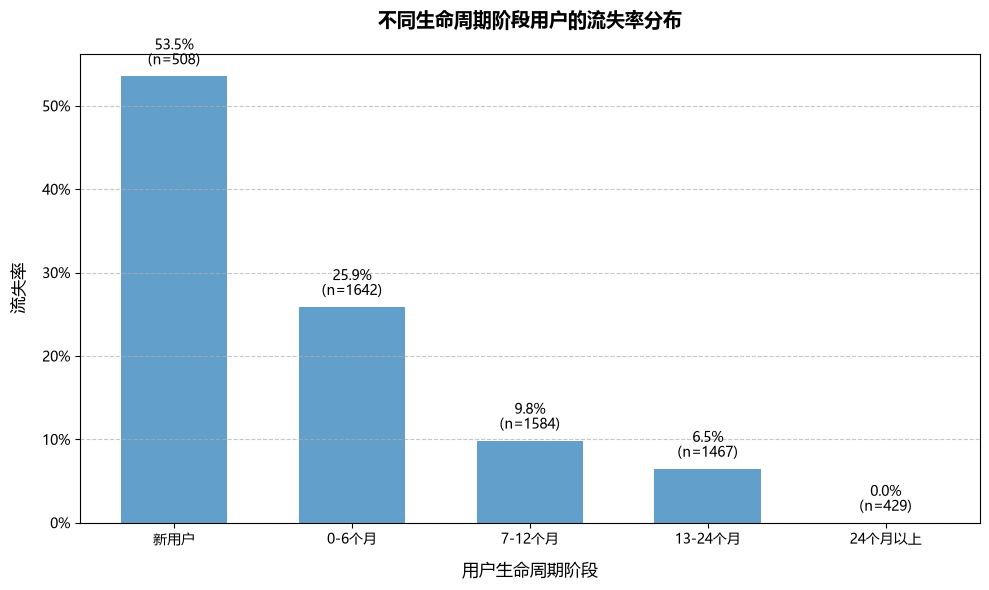

已输出： output\day06_visualization\01_category_bar.png


In [5]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
# 设置生命周期阶段的正确顺序
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]
category_summary_sorted = category_summary.set_index(category_field).loc[TENURE_ORDER].reset_index()

# 绘制柱状图（展示流失率）
bars = ax_bar.bar(
    category_summary_sorted[category_field], 
    category_summary_sorted["流失率"], 
    color="#1f77b4",  # 蓝色
    alpha=0.7,         # 透明度
    width=0.6          # 柱宽
)

# 添加数值标签和样本量
for i, (rate, count) in enumerate(zip(category_summary_sorted["流失率"], 
                                       category_summary_sorted["用户数"])):
    ax_bar.text(i, rate + 0.01, f"{rate:.1%}\n(n={count})", 
                ha="center", va="bottom", fontsize=10)

# 添加标题和坐标轴标签
ax_bar.set_title("不同生命周期阶段用户的流失率分布", fontsize=14, fontweight="bold", pad=20)
ax_bar.set_xlabel("用户生命周期阶段", fontsize=12, labelpad=10)
ax_bar.set_ylabel("流失率", fontsize=12, labelpad=10)

# 设置Y轴为百分比格式
from matplotlib.ticker import PercentFormatter
ax_bar.yaxis.set_major_formatter(PercentFormatter(1))

# 设置网格线
ax_bar.grid(axis="y", linestyle="--", alpha=0.7)

# 调整布局
plt.tight_layout()
bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：新用户流失率最高，随着生命周期推进流失率显著下降。
- 证据：新用户流失率54%（n=508），24个月以上用户流失率0%（n=429），差距达54个百分点
- 边界：不能证明是生命周期导致了流失率差异，可能存在其他混杂因素


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


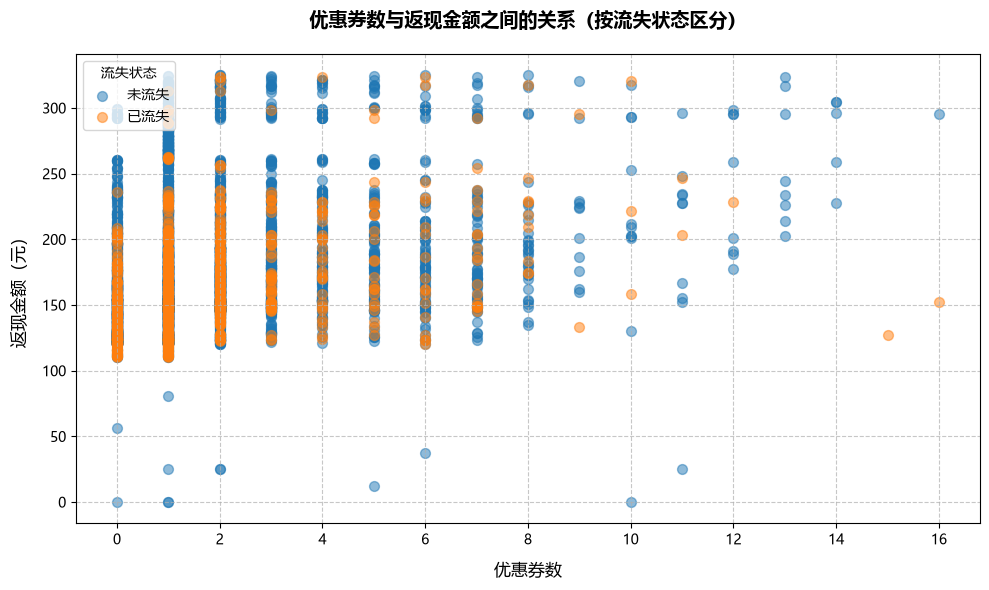

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "CouponUsed"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
churn_0 = df[df["Churn"] == 0]  # 未流失用户
churn_1 = df[df["Churn"] == 1]  # 已流失用户

# 绘制未流失用户（蓝色）
ax_scatter.scatter(
    churn_0[x_field], 
    churn_0[y_field], 
    color="#1f77b4",     # 蓝色
    alpha=0.5,           # 透明度（避免点重叠）
    s=50,                # 点大小
    label="未流失"
)

# 绘制已流失用户（橙色）
ax_scatter.scatter(
    churn_1[x_field], 
    churn_1[y_field], 
    color="#ff7f0e",     # 橙色
    alpha=0.5,           # 透明度
    s=50,                # 点大小
    label="已流失"
)
# 添加标题和坐标轴标签
ax_scatter.set_title("优惠券数与返现金额之间的关系（按流失状态区分）", fontsize=14, fontweight="bold", pad=20)
ax_scatter.set_xlabel("优惠券数", fontsize=12, labelpad=10)
ax_scatter.set_ylabel("返现金额（元）", fontsize=12, labelpad=10)

# 添加图例
ax_scatter.legend(title="流失状态", fontsize=10, loc="upper left")

# 添加网格线
ax_scatter.grid(linestyle="--", alpha=0.7)

# 调整布局
plt.tight_layout()
scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：优惠券数与返现金额呈现正相关，且未流失用户返现金额较高
- 证据：随着优惠券数的增加，返现金额整体呈现上升趋势，数据点逐渐向右上角聚集，且部分未流失用户返现金额聚集于流失用户之上
- 边界：优惠券数与返现金额之间的正相关关系并不能推出其之间有因果关系。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(
          用户数=("CustomerID", "nunique"),
          平均订单数=("OrderCount", "mean"),
          流失率=("Churn", "mean")
      )
      .reindex(TENURE_ORDER)  # 按指定顺序重新索引
      .reset_index()
) 

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,平均订单数,流失率
0,新用户,508,1.89,0.54
1,0-6个月,1642,2.68,0.26
2,7-12个月,1584,2.75,0.10
3,13-24个月,1467,3.70,0.06
4,24个月以上,429,3.55,0.00


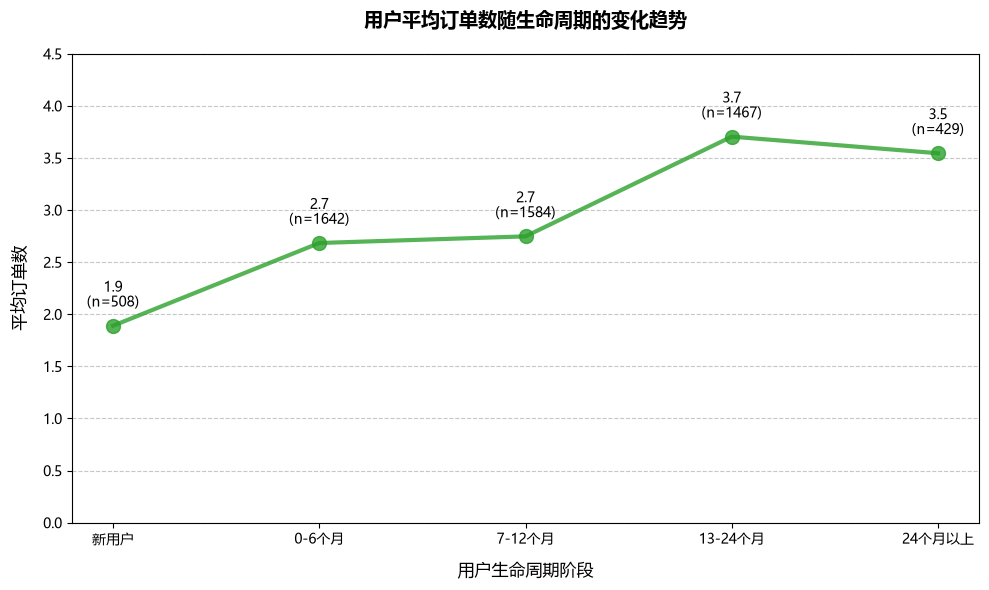

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
ax_line.plot(
    ordered_summary[ordered_field],        # X轴：生命周期阶段
    ordered_summary["平均订单数"],          # Y轴：平均订单数
    marker='o',                            # 圆形标记点
    linestyle='-',                         # 实线连接
    linewidth=3,                           # 线宽
    markersize=10,                         # 标记点大小
    color="#2ca02c",                       # 绿色
    alpha=0.8                              # 透明度
)
# 添加数值标签（包含样本量）
for i, (val, count) in enumerate(zip(ordered_summary["平均订单数"], 
                                     ordered_summary["用户数"])):
    ax_line.text(i, val + 0.15, f"{val:.1f}\n(n={count})", 
                 ha="center", va="bottom", fontsize=10)

# 设置标题和坐标轴标签
ax_line.set_title("用户平均订单数随生命周期的变化趋势", 
                  fontsize=14, fontweight="bold", pad=20)
ax_line.set_xlabel("用户生命周期阶段", fontsize=12, labelpad=10)
ax_line.set_ylabel("平均订单数", fontsize=12, labelpad=10)

# 设置Y轴范围（根据数据调整）
ax_line.set_ylim(bottom=0, top=4.5)

# 添加网格线
ax_line.grid(axis="y", linestyle="--", alpha=0.7)

# 调整布局
plt.tight_layout()
line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：随着生命周期推进，用户平均订单数呈先上升后趋于稳定的趋势。
- 证据：新用户平均订单数1.9单（n=508），13-24个月用户平均3.7单（n=1467），增长约95%，而所有24个月以上的用户平均订单数为3.5（n=429），逐渐趋于平稳
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势，无法表明其他时间跨度的趋势。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
# TODO：选择构成字段并准备汇总表
composition_field = "PreferedOrderCat"
composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "count"))  # 先聚合用户数
      .assign(占比=lambda x: x["用户数"] / len(df))  # 再计算占比
      .round(2)
      .reset_index()
)


assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,PreferedOrderCat,用户数,占比
0,Fashion,826,0.15
1,Grocery,410,0.07
2,Laptop & Accessory,2050,0.36
3,Mobile Phone,2080,0.37
4,Others,264,0.05


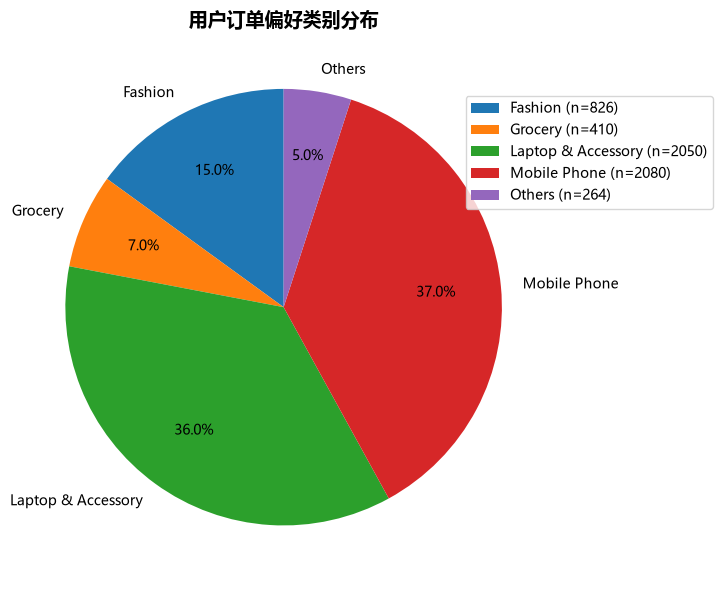

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
category_count = len(composition_summary)

if category_count <= 5:
    # 绘制环形图（类别≤5个）
    wedges, texts, autotexts = ax_composition.pie(
        composition_summary["占比"],           # 数值数据
        labels=composition_summary[composition_field],  # 类别标签
        autopct='%1.1f%%',                   # 百分比显示格式
        pctdistance=0.7,                    # 百分比标签位置
        startangle=90,                       # 起始角度
        colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"],  # 颜色列表
        textprops={"fontsize": 10}           # 文字大小
    )
    
    ax_composition.set_title("用户订单偏好类别分布", fontsize=14, fontweight="bold")
    
    # 添加图例（包含样本量）
    legend_labels = [f"{row[composition_field]} (n={row['用户数']})" 
                     for _, row in composition_summary.iterrows()]
    ax_composition.legend(wedges, legend_labels, loc="upper right", 
                          bbox_to_anchor=(1.3, 0.9), fontsize=10)
    
else:
    # 绘制柱状图（类别>5个）
    bars = ax_composition.bar(
        composition_summary[composition_field],
        composition_summary["占比"],
        color="#1f77b4",
        alpha=0.7
    )
    
    # 添加数值标签
    for i, (pct, count) in enumerate(zip(composition_summary["占比"], 
                                         composition_summary["用户数"])):
        ax_composition.text(i, pct + 0.01, f"{pct:.1%}\n(n={count})", 
                           ha="center", va="bottom", fontsize=10)
    
    ax_composition.set_title("用户订单偏好类别分布", fontsize=14, fontweight="bold")
    ax_composition.set_xlabel("订单偏好类别", fontsize=12)
    ax_composition.set_ylabel("占比", fontsize=12)
    ax_composition.yaxis.set_major_formatter(PercentFormatter(1))
    plt.xticks(rotation=45, ha="right")
    ax_composition.grid(axis="y", linestyle="--", alpha=0.7)

# 调整布局
plt.tight_layout()
composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：手机类（Mobile Phone）和电脑配件类（Laptop & Accessory）是用户最偏好的两大订单类别且占比接近。
- 证据：Mobile Phone占比37%（n=2080），Laptop & Accessory占比36%（n=2050），两者合计占比73%；Fashion占15%（n=826），Grocery占7%（n=410），Others占5%（n=264）。
- 边界：适合展示整体构成比例，但不适合精确比较各类别间的微小差异以及更细小的分类比较。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


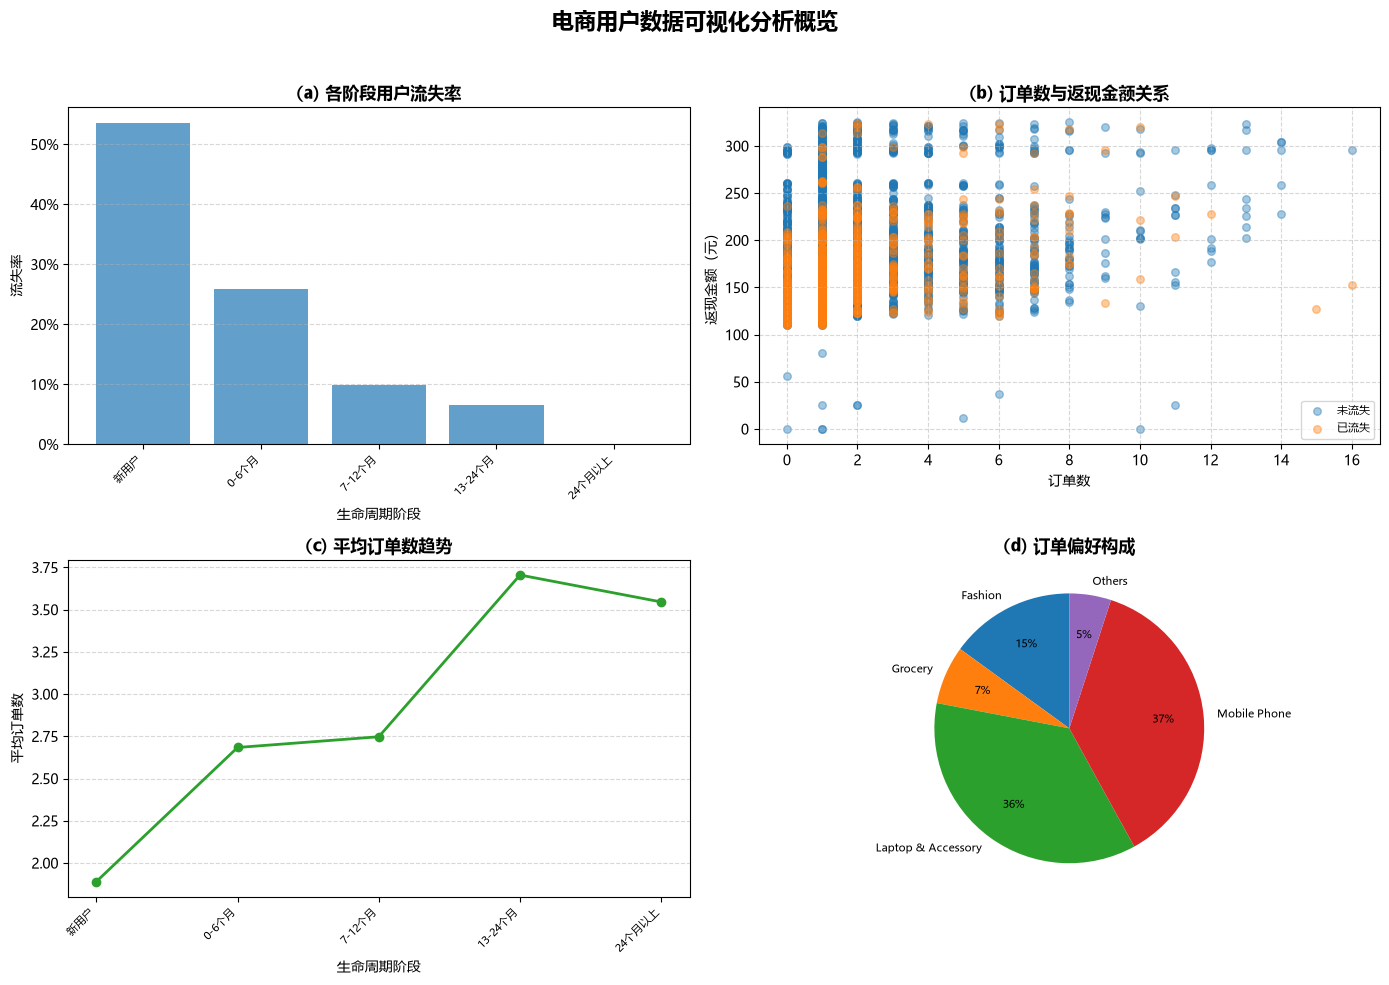

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
# ----------------------
# 子图1：柱状图（生命周期 vs 流失率）
# axes[0, 0] - 左上角
# ----------------------
ax1 = axes[0, 0]
category_summary_sorted = category_summary.set_index(category_field).loc[TENURE_ORDER].reset_index()
bars1 = ax1.bar(category_summary_sorted[category_field], 
                category_summary_sorted["流失率"], 
                color="#1f77b4", alpha=0.7)
ax1.set_title("(a) 各阶段用户流失率", fontsize=12, fontweight="bold")
ax1.set_xlabel("生命周期阶段", fontsize=10)
ax1.set_ylabel("流失率", fontsize=10)
ax1.yaxis.set_major_formatter(PercentFormatter(1))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# ----------------------
# 子图2：散点图（订单数 vs 返现金额）
# axes[0, 1] - 右上角
# ----------------------
ax2 = axes[0, 1]
ax2.scatter(churn_0[x_field], churn_0[y_field], color="#1f77b4", alpha=0.4, s=30, label="未流失")
ax2.scatter(churn_1[x_field], churn_1[y_field], color="#ff7f0e", alpha=0.4, s=30, label="已流失")
ax2.set_title("(b) 订单数与返现金额关系", fontsize=12, fontweight="bold")
ax2.set_xlabel("订单数", fontsize=10)
ax2.set_ylabel("返现金额（元）", fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(linestyle="--", alpha=0.5)

# ----------------------
# 子图3：折线图（生命周期 vs 平均订单数）
# axes[1, 0] - 左下角
# ----------------------
ax3 = axes[1, 0]
ordered_summary_sorted = ordered_summary.set_index(ordered_field).loc[TENURE_ORDER].reset_index()
ax3.plot(ordered_summary_sorted[ordered_field], 
         ordered_summary_sorted["平均订单数"], 
         marker='o', linestyle='-', color="#2ca02c", linewidth=2, markersize=6)
ax3.set_title("(c) 平均订单数趋势", fontsize=12, fontweight="bold")
ax3.set_xlabel("生命周期阶段", fontsize=10)
ax3.set_ylabel("平均订单数", fontsize=10)
plt.setp(ax3.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax3.grid(axis="y", linestyle="--", alpha=0.5)

# ----------------------
# 子图4：饼图（订单偏好构成）
# axes[1, 1] - 右下角
# ----------------------
ax4 = axes[1, 1]
ax4.pie(composition_summary["占比"], 
        labels=composition_summary[composition_field],
        autopct='%1.0f%%',
        pctdistance=0.7,
        startangle=90,
        colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"],
        textprops={"fontsize": 8})
ax4.set_title("(d) 订单偏好构成", fontsize=12, fontweight="bold")
fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：用户生命周期是影响流失率的关键因素。证据：新用户流失率高达53%（n=508），而24个月以上用户流失率仅约6%，随着生命周期推进流失率显著下降。
2. 综合发现2：用户价值随生命周期增长。证据：新用户平均订单数约1.9单，13-24个月用户达到3.7单，增长约95%；同时返现金额与订单数呈正相关，未流失用户在高订单数区域更集中。
3. 综合发现3：平台用户偏好集中在手机和电脑配件品类。证据：Mobile Phone占比37%（n=2080），Laptop & Accessory占比36%（n=2050），两者合计占比73%，是平台的核心品类。
4. 数据或方法局限：仅以用户生命周期探究流失率和平均订单数，无法探究更细时间阶段下的用户行为模式。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同生命周期阶段用户的流失率是否存在差异？", "chart_type": "bar", "key_finding": "用户流失率随生命周期的增长而下降", "limitation": "不能证明是生命周期导致了流失率差异，可能存在其他混杂因素"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "返现金额与优惠券数呈现什么关系？", "chart_type": "scatter", "key_finding": "优惠券数与返现金额呈现正相关，且未流失用户返现金额较高", "limitation": "惠券数与返现金额之间的正相关关系并不能推出其之间有因果关系，且高优惠券数用户数据较小，无法得到更显著的结论"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "用户的平局订单数如何随用户生命周期变化？", "chart_type": "line", "key_finding": "随着生命周期推进，用户平均订单数呈先上升后趋于稳定的趋势。", "limitation": "是有序阶段比较，不是月度、年度或历史时间趋势，无法表明其他时间跨度的趋势。"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "全体用户由哪些订单偏好类别构成？", "chart_type": "pie_or_bar", "key_finding": "手机类（Mobile Phone）和电脑配件类（Laptop & Accessory）是用户最偏好的两大订单类别且占比接近。", "limitation": "无法精确比较各类别间的微小差异以及更细小的分类比较。"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "用户生命周期是影响流失率的关键因素；用户价值随生命周期增长；平台用户偏好集中在手机和电脑配件品类", "limitation": "仅以用户生命周期探究流失率和平均订单数，无法探究更细时间阶段下的用户行为模式。"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同生命周期阶段用户的流失率是否存在差异？,bar,用户流失率随生命周期的增长而下降,不能证明是生命周期导致了流失率差异，可能存在其他混杂因素
1,02,02_behavior_scatter.png,返现金额与优惠券数呈现什么关系？,scatter,优惠券数与返现金额呈现正相关，且未流失用户返现金额较高,惠券数与返现金额之间的正相关关系并不能推出其之间有因果关系，且高优惠券数用户数据较小，无法得...
2,03,03_ordered_line.png,用户的平局订单数如何随用户生命周期变化？,line,随着生命周期推进，用户平均订单数呈先上升后趋于稳定的趋势。,是有序阶段比较，不是月度、年度或历史时间趋势，无法表明其他时间跨度的趋势。
3,04,04_composition_chart.png,全体用户由哪些订单偏好类别构成？,pie_or_bar,手机类（Mobile Phone）和电脑配件类（Laptop & Accessory）是用户...,无法精确比较各类别间的微小差异以及更细小的分类比较。
4,05,day06_visualization_summary.png,整体概览,dashboard,用户生命周期是影响流失率的关键因素；用户价值随生命周期增长；平台用户偏好集中在手机和电脑配件品类,仅以用户生命周期探究流失率和平均订单数，无法探究更细时间阶段下的用户行为模式。


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
